## 1. How are coefficients affected?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes

In [2]:
data = load_diabetes()

In [3]:
df = pd.DataFrame(data.data, columns=data.feature_names)
df['TARGET'] = data.target

In [4]:
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,TARGET
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [5]:
df.shape

(442, 11)

In [8]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    data.data,
    data.target,
    test_size = 0.2,
    random_state = 2
)

In [9]:
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

In [17]:
print(r2_score)
print(type(r2_score))

[]
<class 'list'>


In [18]:
from sklearn.metrics import r2_score

In [19]:
print(type(r2_score))

<class 'function'>


In [20]:
coefs = []
r2_scores = []

for i in [0, 10, 100, 1000]:
    reg = Ridge(alpha=i)
    reg.fit(X_train, y_train)

    coefs.append(reg.coef_.tolist())
    y_pred = reg.predict(X_test)
    r2_scores.append(r2_score(y_test, y_pred))

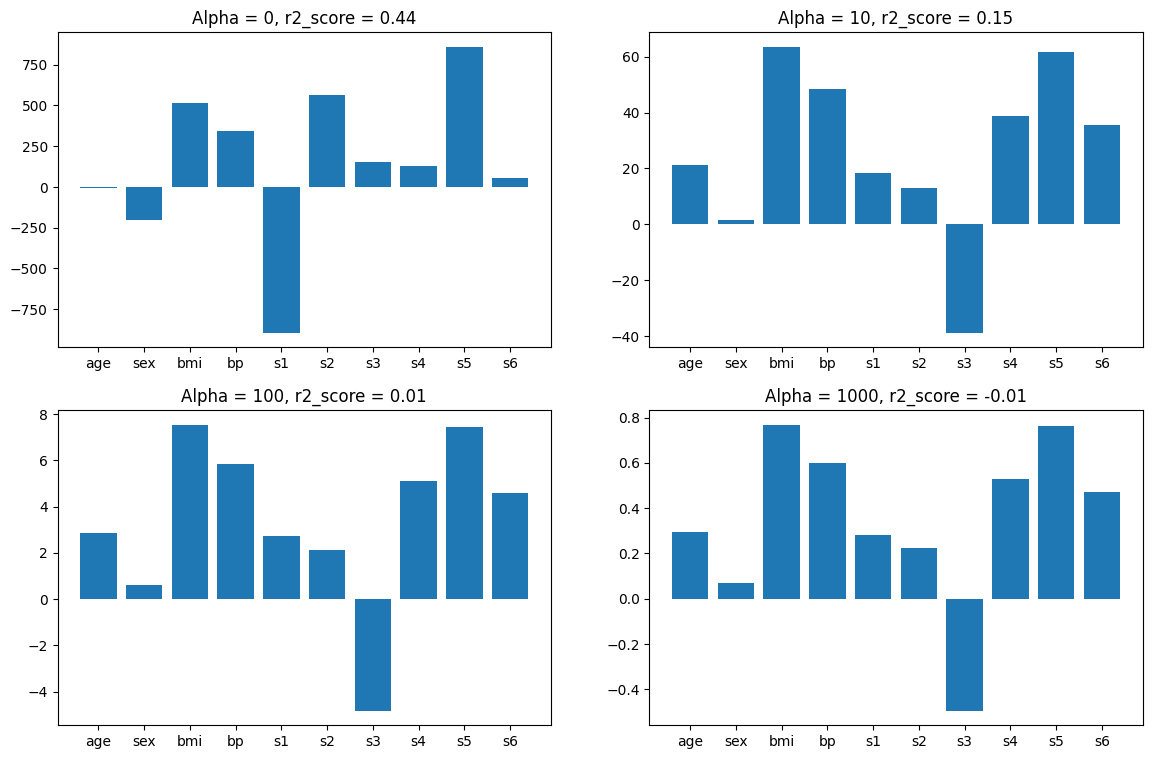

In [22]:
# Create a figure of size 14 x 9
plt.figure(figsize=(14, 9))

# Create subplot at position 1 (2 rows, 2 columns, 1st plot)
plt.subplot(221)

# Plot bar chart of coefficients for alpha = 0
plt.bar(data.feature_names, coefs[0])

# Add title with corresponding R² score
plt.title('Alpha = 0, r2_score = {}'.format(round(r2_scores[0], 2)))


# Create subplot at position 2
plt.subplot(222)

# Plot coefficients for alpha = 10
plt.bar(data.feature_names, coefs[1])

# Add title with R² score
plt.title('Alpha = 10, r2_score = {}'.format(round(r2_scores[1], 2)))


# Create subplot at position 3
plt.subplot(223)

# Plot coefficients for alpha = 100
plt.bar(data.feature_names, coefs[2])

# Add title with R² score
plt.title('Alpha = 100, r2_score = {}'.format(round(r2_scores[2], 2)))


# Create subplot at position 4
plt.subplot(224)

# Plot coefficients for alpha = 1000
plt.bar(data.feature_names, coefs[3])

# Add title with R² score
plt.title('Alpha = 1000, r2_score = {}'.format(round(r2_scores[3], 2)))


# Display all plots
plt.show()

## 2. Higher Coefficients are affected more

In [27]:
# Different alpha values to analyze the effect of Ridge regularization
alphas = [0,0.0001,0.001,0.01,0.1,1,10,100,1000,10000]

# Store coefficients for each alpha value
coefs = []

# Train Ridge Regression model for each alpha
for i in alphas:

    # Create Ridge model with current regularization strength
    reg = Ridge(alpha=i)

    # Train the model
    reg.fit(X_train, y_train)

    # Store the coefficients of the trained model
    coefs.append(reg.coef_.tolist())

In [28]:
input_array = np.array(coefs)

In [30]:
# Create a DataFrame from the coefficient array
# Columns are the feature names of the dataset
coef_df = pd.DataFrame(input_array, columns=data.feature_names)

# Add alpha values as a new column
coef_df['alpha'] = alphas

# Set alpha column as the index of the DataFrame
coef_df.set_index('alpha')

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
alpha,,,,,,,,,,
0.0000,-9.158653,-205.454322,516.693745,340.619999,-895.552002,561.220679,153.893110,126.731397,861.127002,52.421122
0.0001,-9.116119,-205.329219,516.889664,340.549436,-883.423872,551.559582,148.587063,125.353015,856.485935,52.468916
0.0010,-8.761487,-204.313404,518.380608,339.967926,-787.700510,475.282181,106.795253,114.629265,819.745723,52.873349
0.0100,-6.399507,-198.662945,522.056516,336.340595,-383.717571,152.670882,-66.053243,75.608209,659.875219,55.829221
0.1000,6.643733,-172.237474,485.529585,314.675846,-72.940209,-80.588688,-174.463527,83.614710,484.365316,73.585091
1.0000,42.242528,-57.304483,282.172125,198.059395,14.363734,-22.551079,-136.929684,102.023069,260.104294,98.552692
10.0000,21.174024,1.659837,63.659826,48.492858,18.421510,12.875466,-38.915435,38.842475,61.612302,35.505383
100.0000,2.858980,0.629453,7.540605,5.849949,2.710879,2.142135,-4.834047,5.108223,7.448451,4.576129
1000.0000,0.295726,0.069290,0.769004,0.597824,0.282900,0.225936,-0.495607,0.527031,0.761496,0.471029


In [31]:
alphas = [0,0.0001,0.0005,0.001,0.005,0.1,0.5,1,5,10]

coefs = []

for i in alphas:
    reg = Ridge(alpha=i)
    reg.fit(X_train, y_train)

    coefs.append(reg.coef_.tolist())

In [34]:
input_array = np.array(coefs).T

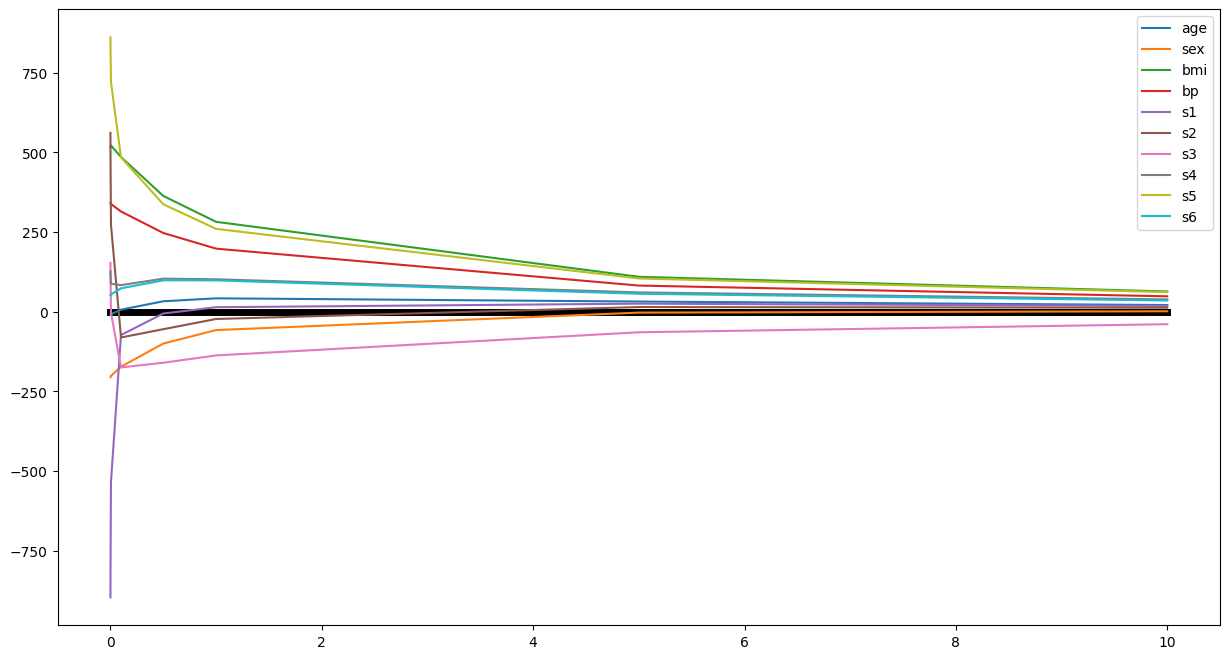

In [35]:
plt.figure(figsize=(15, 8))
plt.plot(alphas, np.zeros(len(alphas)), color='black', linewidth=5)
for i in range(input_array.shape[0]):
    plt.plot(alphas, input_array[i], label=data.feature_names[i])
plt.legend()

## 3. Impact on Bias and Variance

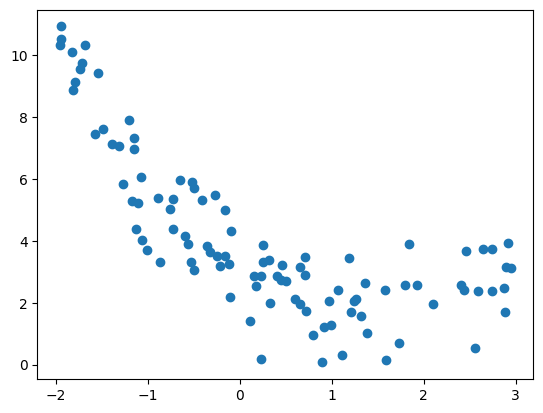

In [38]:
# Number of data points
m = 100

# Generate 100 random X values between -2 and 3
X = 5 * np.random.rand(m, 1) - 2

# Generate target values using a quadratic equation
# and add random noise to make data realistic
y = 0.7 * X**2 - 2 * X + 3 + np.random.randn(m, 1)

# Plot the generated data points
plt.scatter(X, y)

# Display the scatter plot
plt.show()

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X.reshape(100, 1),
    y.reshape(100),
    test_size=0.2,
    random_state=42
)

In [41]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=15)

X_train = poly.fit_transform(X_train)
X_test = poly.transform(X_test)

In [45]:
from mlxtend.evaluate import bias_variance_decomp
# Import function to calculate Bias, Variance, and Expected Loss

# Generate 100 alpha values between 0 and 30
alphas = np.linspace(0, 30, 100)

# Lists to store loss, bias, and variance values
loss = []
bias = []
variance = []

# Check the effect of each alpha value
for i in alphas:

    # Create Ridge Regression model with current alpha
    reg = Ridge(alpha=i)

    # Calculate expected loss, bias, and variance
    avg_expected_loss, avg_bias, avg_var = bias_variance_decomp(
        reg,               # Model
        X_train, y_train,  # Training data
        X_test, y_test,    # Testing data
        loss='mse',        # Use Mean Squared Error
        random_seed=123    # Fix randomness for reproducible results
    )

    # Store expected loss
    loss.append(avg_expected_loss)

    # Store bias
    bias.append(avg_bias)

    # Store variance
    variance.append(avg_var)

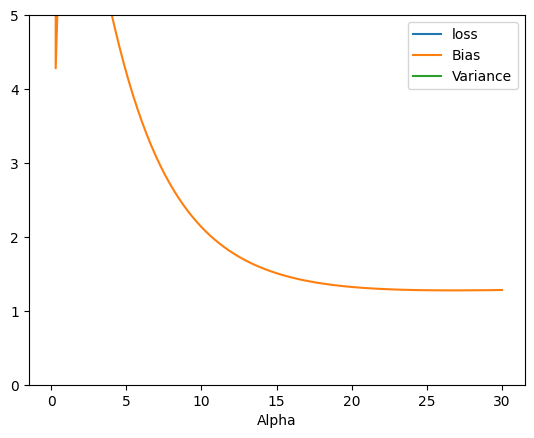

In [47]:
plt.plot(alphas, loss, label='loss')
plt.plot(alphas, bias, label='Bias')
plt.plot(alphas, variance, label='Variance')
plt.ylim(0, 5)
plt.xlabel('Alpha')
plt.legend()

## 4. Effect of Regularization on Loss Function

[29.80613385]
-22.9474455867698


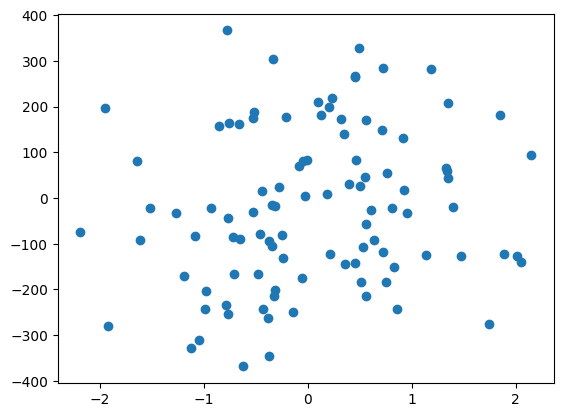

In [48]:
from sklearn.datasets import make_regression

X, y = make_regression(
    n_samples = 100,
    n_features = 1,
    n_informative = 1,
    n_targets = 1,
    noise = 200,
    random_state = 13
)

plt.scatter(X, y)

from sklearn.linear_model import LinearRegression

reg = LinearRegression()
reg.fit(X, y)
print(reg.coef_)
print(reg.intercept_)

In [49]:
# Function to calculate Ridge Regression Loss
# Formula:
# Loss = Σ(y - ŷ)² + αm²
#
# where:
# y  = actual values
# ŷ  = predicted values (mx + b)
# α  = regularization parameter
# m  = coefficient/slope
#
# Ridge loss = Squared Error + Regularization Penalty

def cal_loss(m, alpha):

    # Calculate:
    # Σ(y - prediction)² + αm²
    return np.sum(
        (y - m * X.ravel() + 2.29)**2
    ) + alpha * m * m

In [50]:
def predict(m):
    return m*X - 2.29

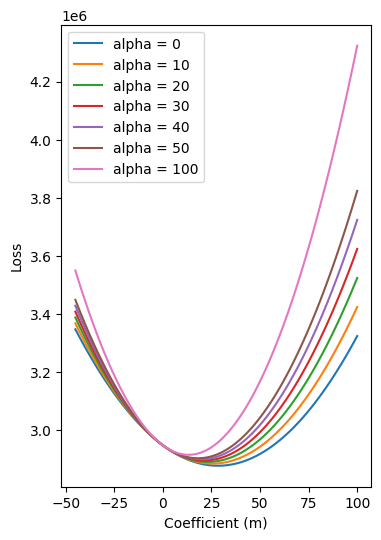

In [52]:
# Generate 100 different values of coefficient (m) from -45 to 100
m = np.linspace(-45, 100, 100)

# Create a figure of size 4 × 6
plt.figure(figsize=(4, 6))

# Try different alpha (regularization) values
for j in [0, 10, 20, 30, 40, 50, 100]:

    # Store loss values for the current alpha
    loss = []

    # Calculate loss for each value of m
    for i in range(m.shape[0]):

        # Calculate Ridge Regression loss
        # Formula:
        # Loss = Σ(y - ŷ)² + αm²
        loss_i = cal_loss(m[i], j)

        # Store the calculated loss
        loss.append(loss_i)

    # Plot coefficient (m) vs loss for the current alpha
    plt.plot(m, loss, label='alpha = {}'.format(j))

# Display legend showing alpha values
plt.legend()

# Label for x-axis (coefficient values)
plt.xlabel('Coefficient (m)')

# Label for y-axis (loss values)
plt.ylabel('Loss')

# Display the graph
plt.show()